In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the cleaned dataset
df = pd.read_csv('Cleaned_Netflix_Dataset.csv')

# Analyze total occurrences per rating category
rating_counts = df['rating'].value_counts()

print("--- Content Breakdown by Rating Category ---")
print(rating_counts)

--- Content Breakdown by Rating Category ---
rating
TV-MA       3205
TV-14       2157
TV-PG        861
R            799
PG-13        490
TV-Y7        333
TV-Y         306
PG           287
TV-G         220
NR            79
G             41
TV-Y7-FV       6
NC-17          3
UR             3
Name: count, dtype: int64


In [4]:
# Unpack comma-separated values in 'listed_in' to extract individual genres
genres_series = df['listed_in'].str.split(', ').explode()
top_genres = genres_series.value_counts().head(10)

print("--- Top 10 Genres on Netflix ---")
print(top_genres)

--- Top 10 Genres on Netflix ---
listed_in
International Movies        2752
Dramas                      2426
Comedies                    1674
International TV Shows      1349
Documentaries                869
Action & Adventure           859
TV Dramas                    762
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64


In [5]:
# Cross-tabulate Rating vs Content Type (Movies vs TV Shows)
rating_type_crosstab = pd.crosstab(df['rating'], df['type'])

print("--- Rating Distribution Across Content Types ---")
print(rating_type_crosstab)

--- Rating Distribution Across Content Types ---
type      Movie  Tv Show
rating                  
G            41        0
NC-17         3        0
NR           75        4
PG          287        0
PG-13       490        0
R           797        2
TV-14      1427      730
TV-G        126       94
TV-MA      2062     1143
TV-PG       540      321
TV-Y        131      175
TV-Y7       139      194
TV-Y7-FV      5        1
UR            3        0


/tmp/ipykernel_1546/4103496940.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_genres.values, y=top_genres.index, palette='crest')


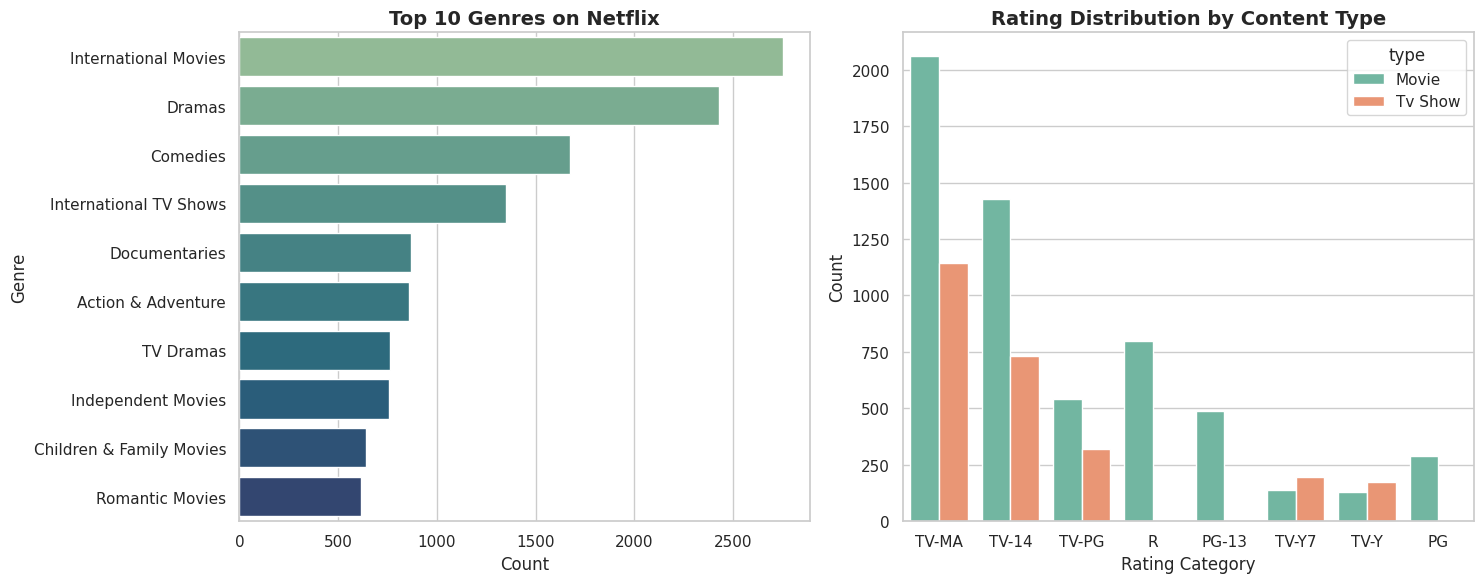

In [6]:
# Set visual style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 6))

# Plot 1: Top 10 Genres
plt.subplot(1, 2, 1)
sns.barplot(x=top_genres.values, y=top_genres.index, palette='crest')
plt.title('Top 10 Genres on Netflix', fontsize=14, fontweight='bold')
plt.xlabel('Count', fontsize=12)
plt.ylabel('Genre', fontsize=12)

# Plot 2: Top Ratings Comparison by Content Type
plt.subplot(1, 2, 2)
top_ratings_list = rating_counts.head(8).index
filtered_df = df[df['rating'].isin(top_ratings_list)]

sns.countplot(
    data=filtered_df,
    x='rating',
    hue='type',
    palette='Set2',
    order=top_ratings_list
)
plt.title('Rating Distribution by Content Type', fontsize=14, fontweight='bold')
plt.xlabel('Rating Category', fontsize=12)
plt.ylabel('Count', fontsize=12)

plt.tight_layout()
plt.show()

In [7]:
print("--- AUDIENCE TARGETING & GENRE INSIGHTS ---")
print("1. Target Audience: Over 60% of Netflix titles are targeted at mature or older teen audiences (TV-MA and TV-14).")
print("2. Top Genres: International Movies, Dramas, and Comedies dominate the platform's overall library.")
print("3. Content Distribution: TV-MA content is heavily represented in both Movies and TV Shows, whereas TV-Y and TV-Y7 (children's programming) have a higher relative proportion of TV Shows.")

--- AUDIENCE TARGETING & GENRE INSIGHTS ---
1. Target Audience: Over 60% of Netflix titles are targeted at mature or older teen audiences (TV-MA and TV-14).
2. Top Genres: International Movies, Dramas, and Comedies dominate the platform's overall library.
3. Content Distribution: TV-MA content is heavily represented in both Movies and TV Shows, whereas TV-Y and TV-Y7 (children's programming) have a higher relative proportion of TV Shows.
